# Traffic Forecasting (1-hour Ahead)

This notebook follows the README requirements:
- leakage-safe feature engineering
- chronological train/test split per junction
- baseline vs XGBoost comparison
- overall and per-junction MAE/RMSE


In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)


In [2]:
from pathlib import Path

candidate_paths = [
    Path('../data/traffic.csv'),
    Path('data/traffic.csv'),
]

DATA_PATH = None
for cp in candidate_paths:
    if cp.exists():
        DATA_PATH = cp
        break

if DATA_PATH is None:
    raise FileNotFoundError('Could not find traffic.csv in ../data or data')

df = pd.read_csv(DATA_PATH)
print('Using data file:', DATA_PATH)
print('Loaded shape:', df.shape)
df.head()


Using data file: ../data/traffic.csv
Loaded shape: (48120, 4)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
print('Columns:', df.columns.tolist())
print('\nDtypes before parsing:')
print(df.dtypes)


Columns: ['DateTime', 'Junction', 'Vehicles', 'ID']

Dtypes before parsing:
DateTime      str
Junction    int64
Vehicles    int64
ID          int64
dtype: object


In [4]:
# Correct parsing for this dataset format (YYYY-MM-DD HH:MM:SS)
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")

print("Invalid timestamps (NaT):", int(df["DateTime"].isna().sum()))
if df["DateTime"].isna().sum() > 0:
    raise ValueError("Found invalid DateTime rows after parsing. Fix this before modeling.")


Invalid timestamps (NaT): 0


In [5]:
# Required ordering for time-series logic
df = df.sort_values(['Junction', 'DateTime']).reset_index(drop=True)

print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', int(df.duplicated().sum()))
print('\nRows per Junction:')
print(df['Junction'].value_counts().sort_index())


Missing values per column:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Duplicate rows: 0

Rows per Junction:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64


In [6]:
# Hourly continuity audit per junction
continuity_report = []
for j, g in df.groupby("Junction"):
    d = g["DateTime"].diff().dropna()
    non_hourly = int((d != pd.Timedelta(hours=1)).sum())
    continuity_report.append({
        "Junction": int(j),
        "rows": len(g),
        "start": g["DateTime"].min(),
        "end": g["DateTime"].max(),
        "non_1h_gaps": non_hourly,
    })

continuity_df = pd.DataFrame(continuity_report)
continuity_df


,Junction,rows,start,end,non_1h_gaps
0,1,14592,2015-11-01,2017-06-30 23:00:00,0
1,2,14592,2015-11-01,2017-06-30 23:00:00,0
2,3,14592,2015-11-01,2017-06-30 23:00:00,0
3,4,4344,2017-01-01,2017-06-30 23:00:00,0


In [7]:
# Target: next hour Vehicles within each junction
df["target"] = df.groupby("Junction")["Vehicles"].shift(-1)

df[["DateTime", "Junction", "Vehicles", "target"]].head(10)


,DateTime,Junction,Vehicles,target
0,2015-11-01 00:00:00,1,15,13.0
1,2015-11-01 01:00:00,1,13,10.0
2,2015-11-01 02:00:00,1,10,7.0
3,2015-11-01 03:00:00,1,7,9.0
4,2015-11-01 04:00:00,1,9,6.0
5,2015-11-01 05:00:00,1,6,9.0
6,2015-11-01 06:00:00,1,9,8.0
7,2015-11-01 07:00:00,1,8,11.0
8,2015-11-01 08:00:00,1,11,12.0
9,2015-11-01 09:00:00,1,12,15.0


In [8]:
# Leakage-safe feature engineering (past values only)

df["hour"] = df["DateTime"].dt.hour
df["day_of_week"] = df["DateTime"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["month"] = df["DateTime"].dt.month

lag_features = [1, 2, 3, 6, 12, 24, 48, 168]
for lag in lag_features:
    df[f"lag_{lag}"] = df.groupby("Junction")["Vehicles"].shift(lag)

shifted = df.groupby("Junction")["Vehicles"].shift(1)
rolling_group = shifted.groupby(df["Junction"])

df["rolling_mean_3"] = rolling_group.transform(lambda s: s.rolling(window=3, min_periods=3).mean())
df["rolling_mean_6"] = rolling_group.transform(lambda s: s.rolling(window=6, min_periods=6).mean())
df["rolling_mean_24"] = rolling_group.transform(lambda s: s.rolling(window=24, min_periods=24).mean())
df["rolling_std_24"] = rolling_group.transform(lambda s: s.rolling(window=24, min_periods=24).std())


In [9]:
required_features = [
    "Junction",
    "Vehicles",
    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_std_24",
]

model_df = df.dropna(subset=["target"] + required_features).copy()
print("Modeling frame shape:", model_df.shape)
model_df[["DateTime", "Junction", "Vehicles", "target"] + required_features[2:8]].head()


Modeling frame shape: (47444, 21)


,DateTime,Junction,Vehicles,target,hour,day_of_week,is_weekend,month,lag_1,lag_2
168,2015-11-08 00:00:00,1,13,16.0,0,6,1,11,15.0,16.0
169,2015-11-08 01:00:00,1,16,11.0,1,6,1,11,13.0,15.0
170,2015-11-08 02:00:00,1,11,8.0,2,6,1,11,16.0,13.0
171,2015-11-08 03:00:00,1,8,10.0,3,6,1,11,11.0,16.0
172,2015-11-08 04:00:00,1,10,10.0,4,6,1,11,8.0,11.0


In [10]:
# Chronological split per junction (80/20 each)
train_idx, test_idx = [], []

for j, g in model_df.groupby("Junction", sort=True):
    g = g.sort_values("DateTime")
    split = int(len(g) * 0.8)
    train_idx.extend(g.index[:split])
    test_idx.extend(g.index[split:])

train_df = model_df.loc[sorted(train_idx)].copy()
test_df = model_df.loc[sorted(test_idx)].copy()

X_train = train_df[required_features]
y_train = train_df["target"]
X_test = test_df[required_features]
y_test = test_df["target"]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train junctions:", sorted(train_df["Junction"].unique().tolist()))
print("Test junctions:", sorted(test_df["Junction"].unique().tolist()))


Train shape: (37954, 18)  Test shape: (9490, 18)
Train junctions: [1, 2, 3, 4]
Test junctions: [1, 2, 3, 4]


In [11]:
def regression_metrics(y_true, y_pred):
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return {"MAE": mae, "RMSE": rmse}

baseline_pred = X_test["Vehicles"].values
baseline_metrics = regression_metrics(y_test.values, baseline_pred)

print("Baseline test metrics:", baseline_metrics)


Baseline test metrics: {'MAE': 4.154478398314015, 'RMSE': 6.168446851907298}


In [12]:
# Train model (XGBoost preferred; fallback if unavailable)
try:
    from xgboost import XGBRegressor
    model = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model_name = "XGBRegressor"
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
    )
    model_name = "RandomForestRegressor"

model.fit(X_train, y_train)
preds = model.predict(X_test)
model_metrics = regression_metrics(y_test.values, preds)

print("Model:", model_name)
print("Model test metrics:", model_metrics)


Model: XGBRegressor
Model test metrics: {'MAE': 3.123999990276341, 'RMSE': 4.987789458470823}


In [13]:
overall_comparison = pd.DataFrame([
    {"model": "Naive baseline (next = current)", **baseline_metrics},
    {"model": model_name, **model_metrics},
])
overall_comparison


,model,MAE,RMSE
0,Naive baseline (next = current),4.154478,6.168447
1,XGBRegressor,3.124000,4.987789


In [14]:
# Per-junction evaluation
per_junction_rows = []
for j in sorted(test_df["Junction"].unique()):
    mask = test_df["Junction"] == j

    y_j = y_test[mask].values
    base_j = X_test.loc[mask, "Vehicles"].values
    pred_j = preds[mask.values]

    base_m = regression_metrics(y_j, base_j)
    model_m = regression_metrics(y_j, pred_j)

    per_junction_rows.append({
        "Junction": int(j),
        "Baseline_MAE": base_m["MAE"],
        "Baseline_RMSE": base_m["RMSE"],
        "Model_MAE": model_m["MAE"],
        "Model_RMSE": model_m["RMSE"],
        "n_test": int(mask.sum()),
    })

per_junction_df = pd.DataFrame(per_junction_rows).sort_values("Junction")
per_junction_df


,Junction,Baseline_MAE,Baseline_RMSE,Model_MAE,Model_RMSE,n_test
0,1,6.259619,8.097863,4.500013,6.487501,2885
1,2,2.939341,3.735631,2.362485,2.995826,2885
2,3,3.715078,6.479778,2.836525,5.321623,2885
3,4,2.597605,3.548298,1.994110,2.910783,835


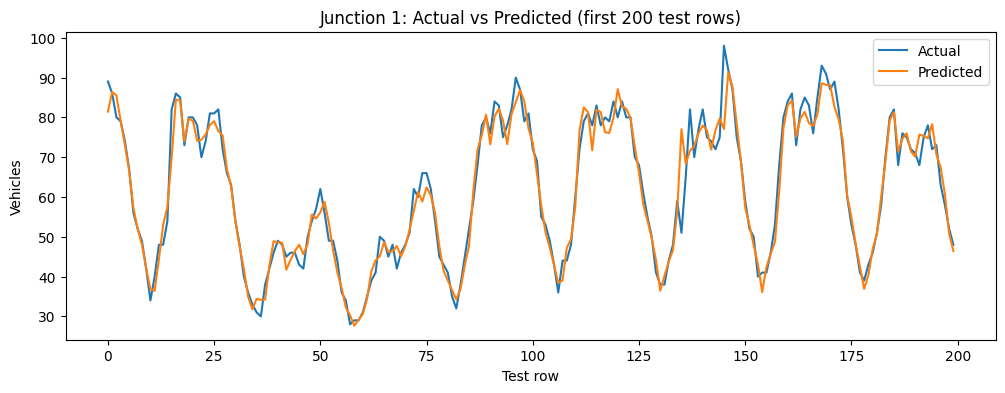

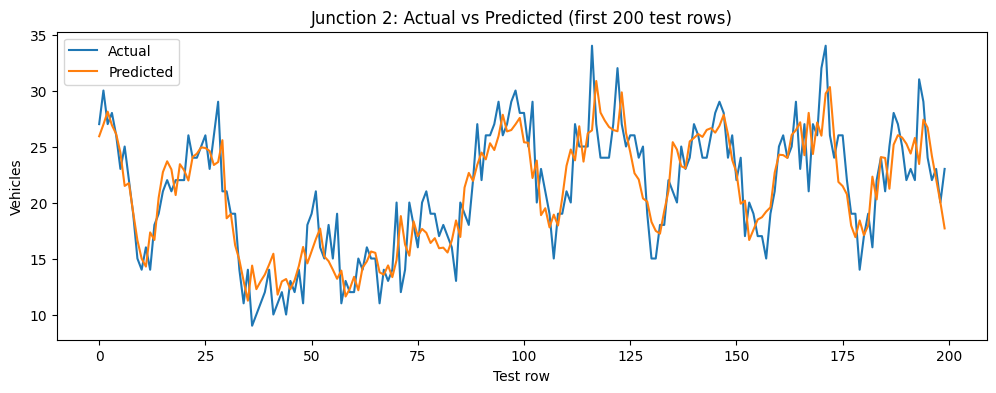

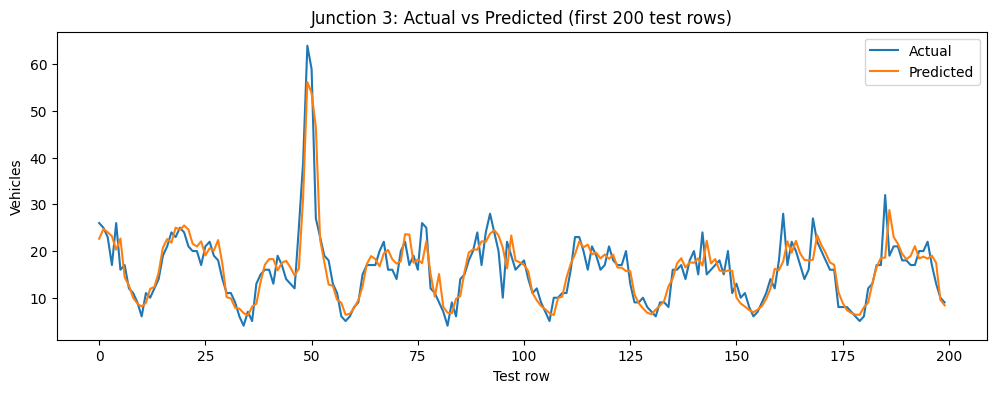

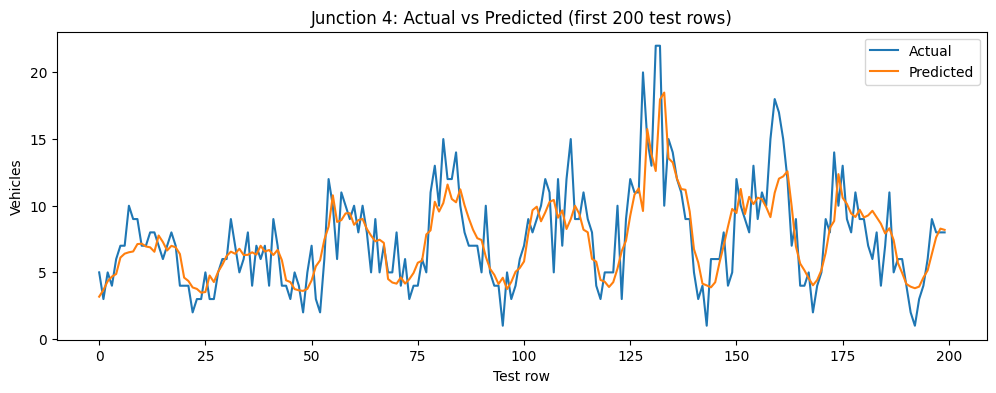

In [15]:
# Visual check: actual vs predicted (first 200 rows of each junction in test)
candidate_output_roots = [Path(".."), Path(".")]
output_root = None
for r in candidate_output_roots:
    if (r / "data").exists() or (r / "notebooks").exists():
        output_root = r
        break
if output_root is None:
    output_root = Path(".")

figures_dir = output_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

for j in sorted(test_df["Junction"].unique()):
    idx = test_df[test_df["Junction"] == j].index
    plot_df = pd.DataFrame({
        "actual": y_test.loc[idx].values,
        "predicted": preds[(test_df["Junction"] == j).values],
    }).reset_index(drop=True)

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["actual"].iloc[:200].values, label="Actual")
    plt.plot(plot_df["predicted"].iloc[:200].values, label="Predicted")
    plt.title(f"Junction {j}: Actual vs Predicted (first 200 test rows)")
    plt.xlabel("Test row")
    plt.ylabel("Vehicles")
    plt.legend()
    plt.savefig(figures_dir / f"junction_{int(j)}_actual_vs_pred.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


In [16]:
# Optional artifact export
from pathlib import Path

candidate_output_roots = [Path('..'), Path('.')]
output_root = None
for r in candidate_output_roots:
    if (r / 'data').exists() or (r / 'notebooks').exists():
        output_root = r
        break
if output_root is None:
    output_root = Path('.')

outputs_dir = output_root / 'outputs'
models_dir = output_root / 'models'
outputs_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

test_output = test_df[['DateTime', 'Junction', 'Vehicles', 'target']].copy()
test_output['baseline_pred'] = baseline_pred
test_output['model_pred'] = preds

overall_comparison.to_csv(outputs_dir / 'metrics_overall.csv', index=False)
per_junction_df.to_csv(outputs_dir / 'metrics_per_junction.csv', index=False)
test_output.to_csv(outputs_dir / 'test_predictions.csv', index=False)

try:
    if model_name == 'XGBRegressor':
        model.save_model(models_dir / 'xgb_traffic_forecast.json')
    else:
        import joblib
        joblib.dump(model, models_dir / 'fallback_model.joblib')
    print('Saved model + outputs to', models_dir, 'and', outputs_dir)
except Exception as e:
    print('Model save skipped:', e)


Saved model + outputs to ../models and ../outputs
